# ENGR 1451/2451 — Weekly Assignment 3
**10 points**

This assignment applies programming, normal-approximation, and central-limit-theorem ideas.


**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

No external data file is needed for this assignment.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


## LE3-1. Detecting abrupt changes in a sequence (2 pts)

Thickness is measured at consecutive positions along a coated sample. A change of **5 nm or more in magnitude** between neighboring positions is considered abrupt.

### A. Loop solution (1 pt)

Using `range`, an `if` statement, and `.append()`, calculate each change from one position to the next and store it in `changes_loop`. Store the position pairs with abrupt changes in `abrupt_pairs_loop`. **Report position numbers starting at 1**; for example, `(1, 2)` means the change from the first measurement to the second measurement.


In [7]:
thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]
settings = {"abrupt_change_nm": 5}

changes_loop = []
abrupt_pairs_loop = []

for i in range(len(thickness_nm) - 1):
    change = thickness_nm[i+1] - thickness_nm[i]
    changes_loop.append(change)
    
print("change loop list:", changes_loop)

threshold = settings["abrupt_change_nm"]
    
for i in range(len(changes_loop)):
    if abs(changes_loop[i]) >= threshold:
        first_m = i + 1
        second_m = i + 2
        measurment_set = (first_m, second_m)
        abrupt_pairs_loop.append(measurment_set)

print("pair_loops:", abrupt_pairs_loop)



change loop list: [2, -1, 6, 1, -3, 6, -1]
pair_loops: [(3, 4), (6, 7)]


### B. Vectorized solution (1 pt)

Convert the data to a NumPy array and use `np.diff()` to calculate the same changes without an explicit loop. Use a Boolean mask to identify abrupt changes. Verify agreement with the loop solution and report the affected position pairs.

**Answer:**


In [8]:
thickness_nm_vector = np.array(thickness_nm)
threshold = settings["abrupt_change_nm"]

changes_loop_vector = np.diff(thickness_nm_vector)
print("change loop list vector:", changes_loop_vector)

pair_loops_vector = []

change_elements = abs(changes_loop_vector) >= threshold
indices = np.where(change_elements)[0]

for indice in indices:
    pair_loops_vector.append((indice+1, indice +2))

print("pair_loops_vector:", pair_loops_vector)


change loop list vector: [ 2 -1  6  1 -3  6 -1]
pair_loops_vector: [(3, 4), (6, 7)]


In [9]:
#comarison
change_check = np.array_equal(changes_loop, changes_loop_vector)

pair_check = np.array_equal(abrupt_pairs_loop, pair_loops_vector)

if (change_check and pair_check): 
    print("Both methods have the same answer.")
else:
    print("Methods do not have the same answer.")

Both methods have the same answer.


## LE3-2. Raw scores and a normal approximation (2 pts)

For Part B, use a normal model with **mean = 50** and **SD = 10**. **Do not estimate these values from the raw scores.**

### A. Density histogram from raw data (1 pt)

Make a **density histogram** using the supplied equal-width bins. Then use `np.histogram(..., density=True)` to calculate the density heights and verify

\[
\sum_i (\text{density}_i)(\text{bin width}_i)=1.
\]

Also calculate the sum of the density heights. Why do the heights themselves not need to sum to 1?


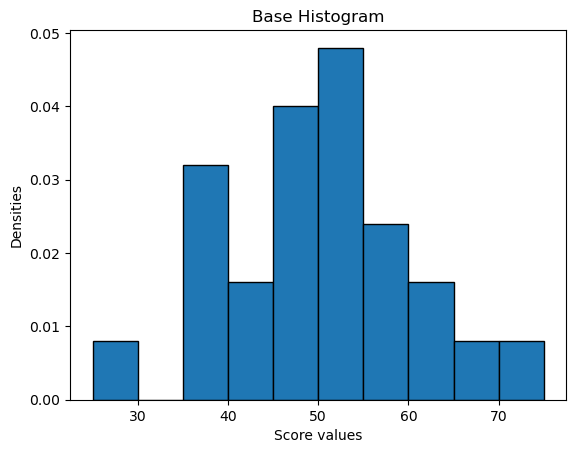

TRUE - Total area sum = 1.0
Heights sum 0.2


In [10]:
scores = np.array([
    39, 41, 47, 58, 65, 37, 37, 49, 56, 59, 62, 36, 48,
    52, 64, 29, 44, 47, 49, 52, 53, 54, 72, 50, 50
])

bins = np.arange(25, 76, 5)

# Create the density histogram and verify its total area.
plt.hist(scores, bins=bins, edgecolor="black", density=True)
plt.xlabel("Score values")
plt.ylabel("Densities")
plt.title("Base Histogram")
plt.show()

heights, edges = np.histogram(scores, bins=bins, density=True)

total_area = np.sum(heights * np.diff(edges))

if total_area == 1:
    print("TRUE - Total area sum =", total_area)
else:
    print("FALSE - Total area sum is not 1")

heights_sum = np.sum(heights)
print("Heights sum", heights_sum)

**Answer:**
The heights themselves do not sum to 1 because they represent density (relative frequency divided by bin width). However, when multiplying the heights by the bin widths, the equation calculates the total area. This accounts for all data points, which is why the total area equals 1.

### B. Approximation versus actual data (1 pt)

Using the supplied normal model with **mean = 50** and **SD = 10**, estimate the percentage and number of the 25 scores within **1.25 SDs** of the mean. Then count how many raw scores actually fall in that interval. Round the fitted count to the nearest whole student and compare.


In [11]:
# Your normal approximation and observed count here

mean = 50
std = 10

within_125 = np.abs(scores - mean) <= (1.25 * std)
count = np.sum(within_125)
percentage = (count / len(scores)) *100
                          
print(f"Number of scores within 1.25 SD: {count}")
print(f"Percentage of scores within 1.25 SD: {percentage}%")

upper_x = mean + std * 1.25
lower_x = mean - std * 1.25

upper_endpoint = (upper_x - mean) / std
lower_endpoint = (lower_x - mean) / std

fit_percentage = norm.cdf(upper_endpoint) - norm.cdf(lower_endpoint)
fit_count = round(fit_percentage * 25)

print(f"Number of scores within 1.25 SD with fitted values: {fit_count}")
print(f"Percentage of scores within 1.25 SD with fitted values: {round(fit_percentage * 100,1)}%")


Number of scores within 1.25 SD: 18
Percentage of scores within 1.25 SD: 72.0%
Number of scores within 1.25 SD with fitted values: 20
Percentage of scores within 1.25 SD with fitted values: 78.9%


**Answer:**
The results show that the fitted normal distribution predicts slightly higher values than those observed in the data. Specifically, the fitted distribution predicts that 20 students, or 78.9%, would fall within 1.25 standard deviations of the mean, while the observed data include 18 students, or 72.0%. This difference corresponds to only 2 out of 25 students, indicating that the fitted normal distribution provides a reasonably close approximation for the proportion of scores within this interval. However, this comparison only evaluates the number of observations within 1.25 standard deviations of the mean and does not by itself confirm that the overall distribution of the observed data is normal.


## LE3-3. Normal model for engineering specifications (4 pts)

Shaft diameters are modeled by a normal curve with \(\mu=10.00\) mm and \(\sigma=0.12\) mm. The acceptable range is **9.80–10.20 mm**. Assume the normal model is appropriate.

### A. Fraction meeting specification (1.5 pts)

Calculate the fitted percentages **below**, **within**, and **above** specification, and check that they total about 100%. Why are the two tail percentages equal?


In [12]:
mean_diameter = 10.00
std_diameter = 0.12
lower_spec = 9.80
upper_spec = 10.20

# Create the normal model and calculate the probabilities here
upper_end_x = 10.20
lower_end_x = 9.80

upper_end_point = (upper_end_x - mean_diameter) / std_diameter
#print(upper_end_point)
lower_end_point = (lower_end_x - mean_diameter) / std_diameter
#print(lower_end_point)

upper_end_percentage = norm.cdf(upper_end_x, loc = mean_diameter, scale = std_diameter)*100
print(f"Upper end percentage {round(upper_end_percentage,2)}%")
lower_end_percentage = norm.cdf(lower_end_x, loc = mean_diameter, scale = std_diameter)*100
print(f"Lower end percentage {round(lower_end_percentage,2)}%")

percentage_above = 100 - upper_end_percentage
percentage_within = upper_end_percentage - lower_end_percentage
percentage_below = 100 - percentage_above - percentage_within

print(f"Percentage above: {round(percentage_above,2)}%")
print(f"Percentage within: {round(percentage_within,2)}%")
print(f"Percentage below: {round(percentage_below,2)}%")

Upper end percentage 95.22%
Lower end percentage 4.78%
Percentage above: 4.78%
Percentage within: 90.44%
Percentage below: 4.78%


**Answer:**
The two tail percentages are equal because the normal distribution is symmetric and the specification limits are equally distant from the mean. The lower specification limit, 9.80, is 0.20 below the mean of 10.00, while the upper specification limit, 10.20, is 0.20 above the mean. Therefore, their z-scores have the same magnitude but opposite signs, so the areas in the two tails are equal.

### B. Upper 99th-percentile threshold (1 pt)

Find an upper threshold that only **1%** of shafts are expected to exceed. Use `ppf` or `isf`, then verify the result with a right-tail probability.


In [13]:
upper_threshold = norm.ppf(0.99, loc = mean_diameter, scale = std_diameter)
print(f"Upper 99th-percentile threshold: {upper_threshold:.2f} mm")

right_tail_prob = norm.sf(upper_threshold, loc=mean_diameter, scale=std_diameter)
print(f"Verified right-tail probability: {right_tail_prob:.2%}")

Upper 99th-percentile threshold: 10.28 mm
Verified right-tail probability: 1.00%


### C. Process drift (1.5 pts)

Suppose the process mean shifts to **10.05 mm**, while $\sigma=0.12$ mm and the specifications stay fixed. Recalculate the percentages below and above specification and the total percentage rejected. Compare with the original process. Which side now causes most rejections, and why?


In [14]:
shifted_mean = 10.05

# Your shifted-process calculations here
upper_end_point_moved = (upper_end_x - shifted_mean) / std_diameter
#print(upper_end_point)
lower_end_point_moved = (lower_end_x - shifted_mean) / std_diameter
#print(lower_end_point)

upper_end_percentage_moved = norm.cdf(upper_end_x, loc = shifted_mean, scale = std_diameter)*100
print(f"Upper end percentage {round(upper_end_percentage_moved,2)}%")
lower_end_percentage_moved = norm.cdf(lower_end_x, loc = shifted_mean, scale = std_diameter)*100
print(f"Lower end percentage {round(lower_end_percentage_moved,2)}%")

percentage_above_moved = 100 - upper_end_percentage_moved
percentage_within_moved = upper_end_percentage_moved - lower_end_percentage_moved
percentage_below_moved = 100 - percentage_above_moved - percentage_within_moved

print(f"Percentage above: {round(percentage_above_moved,2)}%")
print(f"Percentage below: {round(percentage_below_moved,2)}%")

Upper end percentage 89.44%
Lower end percentage 1.86%
Percentage above: 10.56%
Percentage below: 1.86%


**Answer:**
When the process mean shifts upward from 10.00 mm to 10.05 mm, the entire normal distribution moves closer to the upper specification limit (10.20 mm) and farther from the lower specification limit (9.80 mm). As a result, the percentage above the upper specification limit increases from 4.78% to 10.56%, while the percentage below the lower specification limit decreases from 4.78% to 1.86%. The total percentage rejected therefore increases from 9.56% to 12.42%. The upper specification limit now causes most of the rejections because it is closer to the shifted mean. This places a larger portion of the distribution beyond the upper limit, while less of the distribution falls below the lower limit.

## LE3-4. CLT with a skewed process (2 pts)

For this exercise, we will start with an **exponential distribution**. An exponential distribution is a continuous distribution often used to model **waiting times**. It only produces positive values and is **strongly right-skewed**: short waiting times are common, while very long waiting times are possible but less common.

In NumPy,

```python
rng.exponential(scale=4.0, ...)
```

uses an exponential distribution with a **mean of 4 minutes**. We are using it because it gives us a clearly **non-normal starting distribution**, which makes the effect of the central limit theorem easier to see.

Run the starter code below to simulate the waiting times and view the distribution of individual observations.

### A. Averages of 4 versus 40 observations (1.5 pts)

Calculate the average of the first **4** waiting times in each row and the average of all **40** waiting times in each row.

1. For each set of averages, calculate the **mean** and **sample standard deviation** and summarize the results in a table.
2. Make a separate **density histogram** for each set of averages.
3. Compare the observed ratio of the sample standard deviations,

$
\frac{s_{\bar X_4}}{s_{\bar X_{40}}},
$

with the value predicted by the $1/\sqrt{n}$ relationship:

$
\frac{1/\sqrt{4}}{1/\sqrt{40}}
=
\sqrt{\frac{40}{4}}
=
\sqrt{10}
\approx 3.16.
$

Does your simulation approximately agree with this prediction?

Here, $s_{\bar X_4}$ is the sample standard deviation of the 5,000 simulated averages of 4 observations, and $s_{\bar X_{40}}$ is the sample standard deviation of the 5,000 simulated averages of 40 observations.


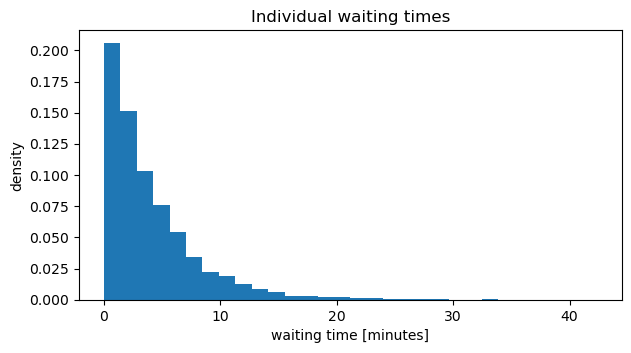

  statistics     N = 4    N = 40
0       mean  4.041293  3.995643
1  sample SD  2.040821  0.628392
Observed SD ratio: 3.25
Predicted SD ratio: 3.16


In [19]:
rng = np.random.default_rng(1451)
waiting_times = rng.exponential(scale=4.0, size=(5000, 40))

# First, look at the distribution of individual waiting times.
plt.figure(figsize=(7, 3.5))
plt.hist(waiting_times[:, 0], bins=30, density=True)
plt.xlabel("waiting time [minutes]")
plt.ylabel("density")
plt.title("Individual waiting times")
plt.show()

# The row averages are provided so you can focus on the CLT.
means_4 = waiting_times[:, :4].mean(axis=1)
means_40 = waiting_times.mean(axis=1)


# Your summary table, SD comparison, and plots here
mean_4 = means_4.mean()
std_4 = means_4.std(ddof=1)
mean_40 = means_40.mean()
std_40 = means_40.std(ddof=1)

df = pd.DataFrame({"statistics": ["mean", "sample SD"],
                   "N = 4": [mean_4, std_4],
                   "N = 40": [mean_40, std_40],
                  })
print(df)


observed_ratio = std_4 / std_40
predicted_ratio = np.sqrt(10)

print(f"Observed SD ratio: {observed_ratio:.2f}")
print(f"Predicted SD ratio: {predicted_ratio:.2f}")

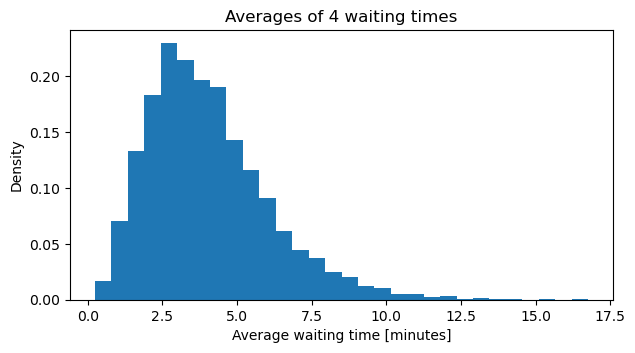

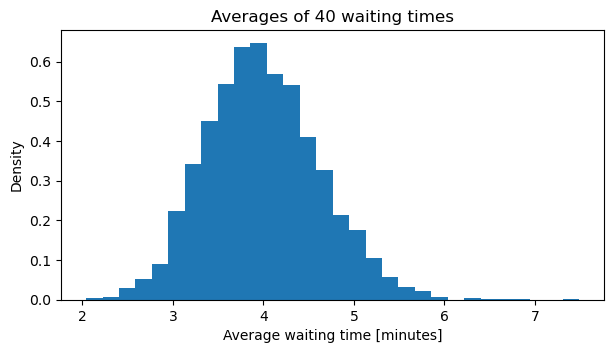

In [20]:
plt.figure(figsize=(7, 3.5))
plt.hist(means_4, bins=30, density=True)
plt.xlabel("Average waiting time [minutes]")
plt.ylabel("Density")
plt.title("Averages of 4 waiting times")
plt.show()

plt.figure(figsize=(7, 3.5))
plt.hist(means_40, bins=30, density=True)
plt.xlabel("Average waiting time [minutes]")
plt.ylabel("Density")
plt.title("Averages of 40 waiting times")
plt.show()

Both sets of sample averages have means close to the population mean of 4 minutes. However, the sample standard deviation decreases from approximately 2.04 for averages of 4 observations to approximately 0.63 for averages of 40 observations. The observed ratio of the two standard deviations is about 3.25, which is close to the theoretical value of 3.16 predicted by the relationship. Therefore, the simulation approximately agrees with the theoretical prediction.

The histogram of averages based on 4 observations is still somewhat right-skewed, reflecting the shape of the original exponential distribution. In contrast, the averages based on 40 observations form a much more symmetric and approximately normal-shaped distribution. The distribution for (n=40) is also noticeably narrower, showing that averages become less variable as the sample size increases. This illustrates the central limit theorem.

### B. Interpret (0.5 pt)

Compare center, spread, and shape for the two distributions of averages. Explain what the simulation illustrates about the **central limit theorem**, and distinguish it from the **law of large numbers**.

**Answer:**
The two distributions of sample averages have nearly the same center, with both means close to the population mean of 4 minutes. However, the distribution of averages for (n=40) has a much smaller spread than the distribution for (n=4), as shown by its lower sample standard deviation. In terms of shape, the averages based on 4 observations are still somewhat right-skewed, while the averages based on 40 observations are much more symmetric and approximately normal.

This simulation illustrates the central limit theorem because, as the sample size increases, the distribution of the sample mean becomes more nearly normal even though the original waiting-time distribution is strongly right-skewed. It also shows that the spread of the sample mean decreases as the sample size increases. This is different from the law of large numbers, which states that the sample mean tends to get closer to the true population mean as the sample size increases. In other words, the central limit theorem describes the shape and spread of the distribution of sample means, while the law of large numbers describes how the sample mean converges toward the population mean.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA3",
  "export_n": 1,
  "session_date": "2026-09-22",
  "messages": [
    {"i": 1, "who": "student", "text": "i do not quite undesrnat waht the output needs to be. the change is it the chage between each element in the list?\n\nA. Loop solution (1 pt)\nUsing `range`, an `if` statement, and `.append()`, calculate each change from one position to the next and store it in `changes_loop`. Store the position pairs with abrupt changes in `abrupt_pairs_loop`. Report position numbers starting at 1; for example, `(1, 2)` means the change from the first measurement to the second measurement.\n\ni understand how to do it but i do not see why i need range for that"},
    {"i": 2, "who": "tutor", "text": "Explained that a change is the difference between consecutive elements, that changes_loop holds seven signed differences from eight measurements, and that abrupt_pairs_loop holds position labels as tuples rather than values. Showed a toy list. Explained that range gives the counter i needed to reach both values[i] and values[i+1] and to build 1-based position numbers, and that the -1 prevents an IndexError."},
    {"i": 3, "who": "student", "text": "can you give me more deilts in temrs of waht this abrupt pair loop needs to be becausei do not get it waht is 3 , 4. like the third element is much higher than the 4th? or what"},
    {"i": 4, "who": "tutor", "text": "Explained that a pair is an address for a step between two positions, not a comparison or ranking of two values. Used a labeled toy diagram. Noted that direction does not matter because the rule is magnitude, so abs is required, and that the 1-based positions for counter i are i+1 and i+2."},
    {"i": 5, "who": "student", "text": "so for a list of 5 eleents the abrcutp pair would be 4,5?"},
    {"i": 6, "who": "tutor", "text": "Clarified that list length determines which pairs are possible, not which are abrupt. Listed the four candidate steps for five measurements and gave two toy lists of the same length with different results, to show the if is what selects."},
    {"i": 7, "who": "student", "text": "so abrupt is when we have a higher difference between the elements? how do i define a trehold then"},
    {"i": 8, "who": "tutor", "text": "Pointed to settings[\"abrupt_change_nm\"] as the supplied threshold and explained dictionary access. Explained that 5 or more means >= not >, and that abs strips the sign, showing the generic shape of the condition."},
    {"i": 9, "who": "student", "text": "oh it is alredty provided in the code it is 5 okay i get it so i get the differnce , between them in absolute value then i check which pari had the higher trehold"},
    {"i": 10, "who": "tutor", "text": "Corrected two points: changes_loop stores the signed change while abs belongs only in the test, and changes_loop.append must sit outside the if. Also corrected the phrasing that steps have thresholds of their own, and noted the number of flagged pairs is not fixed at one."},
    {"i": 11, "who": "student", "text": "thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\nfor i in range(len(thickness_nm) - 1):\n    change = thickness_nm[i+1] - thickness_nm[i]\n    changes_loop.append(change)\n    \nprint(\"change loop list:\", changes_loop)\n\nfor i in range(len(changes_loop)):\n    if changes_loop[i] >= settings[\"abrupt_change_nm\"]:\n        first_m = i + 1\n        second_m = i + 2\n        measurment_set = (first_m, second_m)\n        abrupt_pairs_loop.append(measurment_set)\n\nprint(\"pair_loops:\", abrupt_pairs_loop)\n\nchange loop list: [2, -1, 6, 1, -3, 6, -1]\npair_loops: [(3, 4), (6, 7)]", "code": true},
    {"i": 12, "who": "tutor", "text": "Confirmed changes_loop and the 1-based pair construction were correct and that the two-loop split still satisfies the named tools. Flagged that the condition tests the signed change rather than the magnitude, so the implemented rule does not match the printed rule even though this data happens to give the right pairs. Suggested a self-test with a modified value."},
    {"i": 13, "who": "student", "text": "thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\nfor i in range(len(thickness_nm) - 1):\n    change = thickness_nm[i+1] - thickness_nm[i]\n    changes_loop.append(change)\n    \nprint(\"change loop list:\", changes_loop)\n\nfor i in range(len(changes_loop)):\n    if abs(changes_loop[i]) >= settings[\"abrupt_change_nm\"]:\n        first_m = i + 1\n        second_m = i + 2\n        measurment_set = (first_m, second_m)\n        abrupt_pairs_loop.append(measurment_set)\n\nprint(\"pair_loops:\", abrupt_pairs_loop)\n\nchange loop list: [2, -1, 6, 1, -3, 6, -1]\npair_loops: [(3, 4), (6, 7)]", "code": true},
    {"i": 14, "who": "tutor", "text": "Confirmed LE3-1A complete: the implemented rule now matches the printed rule, seven signed changes and pairs (3,4) and (6,7) both correct. Asked whether to continue to part B."},
    {"i": 15, "who": "student", "text": "B. Vectorized solution (1 pt)\nConvert the data to a NumPy array and use `np.diff()` to calculate the same changes without an explicit loop. Use a Boolean mask to identify abrupt changes. Verify agreement with the loop solution and report the affected position pairs.\nAnswer:\n\nthickness_nm_vector = np.array(thickness_nm)\n\nchanges_loop_vector = np.diff(thickness_nm_vector)\nprint(\"change loop list vector:\", changes_loop_vector)\n\npair_loops_vector = []\n\nchange_elements = abs(changes_loop_vector) >= threshold\nindices = np.where(change_elements)[0]\n\nfor indice in indices:\n    pair_loops_vector.append((indice, indice +1))\n\nprint(\"pair_loops_vector:\", pair_loops_vector)\n\nchange loop list vector: [ 2 -1  6  1 -3  6 -1]\npair_loops_vector: [(2, 3), (5, 6)]", "code": true},
    {"i": 16, "who": "tutor", "text": "Confirmed np.diff, the mask, and np.where were correct. Flagged three issues: pairs came out 0-based and need the same shift used in part A; threshold is undefined in this cell and risks a NameError after Restart and Run All; the verification is missing. Explained np.array_equal for arrays and == for lists of tuples, and noted the Answer sentence is graded prose."},
    {"i": 17, "who": "student", "text": "B. Vectorized solution (1 pt)\n[same cell with (indice+1, indice +2)]\npair_loops_vector: [(3, 4), (6, 7)]", "code": true},
    {"i": 18, "who": "tutor", "text": "Confirmed the offset fix. Restated the two open items: threshold undefined in the cell, and no verification in code. Noted the variable names referencing loops were misleading for part B."},
    {"i": 19, "who": "student", "text": "[cell with threshold = settings[\"abrupt_change_nm\"] added, plus a comparison cell printing both results and then print(\"Both methods gave the same answer.\")]", "code": true},
    {"i": 20, "who": "tutor", "text": "Confirmed threshold now defined. Explained that a hard-coded print asserts agreement rather than testing it, and that the prompt asks the code to verify. Pointed to np.array_equal returning a computed boolean, and distinguished a printed sentence from the Answer markdown cell."},
    {"i": 21, "who": "student", "text": "change_check = np.array_equal(changes_loop, changes_loop_vector)\n\npair_check = np.array_equal(abrupt_pairs_loop, pair_loops_vector)\n\nif (pair_check and pair_check):\n    print(\"Both methods have the same answer.\")\nelse:\n    print(\"Methods do not have the same answer.\")", "code": true},
    {"i": 22, "who": "tutor", "text": "Confirmed both checks are now computed from the data. Flagged that the if tests pair_check twice so change_check is never used. Noted that and is correct for single booleans but & with parentheses will be needed for array conditions in LE3-2B."},
    {"i": 23, "who": "student", "text": "[same cell with if (change_check and pair_check)]", "code": true},
    {"i": 24, "who": "tutor", "text": "Confirmed the bug closed and LE3-1B code complete, with only the Answer markdown cell remaining."},
    {"i": 25, "who": "student", "text": "it is good now we solved it"},
    {"i": 26, "who": "tutor", "text": "Accepted and asked whether to continue to LE3-2 or stop."},
    {"i": 27, "who": "student", "text": "okay i do not quite undersatn this task:\n\nMake a density histogram using the supplied equal-width bins. Then use `np.histogram(..., density=True)` to calculate the density heights and verify\n[ \\sum_i (\\text{density}_i)(\\text{bin width}_i)=1. ]\nAlso calculate the sum of the density heights. Why do the heights themselves not need to sum to 1?\n\ndo i need to create a density histogram first without np.hist() then to use np.hist"},
    {"i": 28, "who": "tutor", "text": "Distinguished plt.hist (draws) from np.histogram (computes, returning heights then edges) and explained both deliverables are wanted. Explained density as area, getting widths via np.diff(edges), and that heights.sum() is a separate second number whose explanation is graded prose."},
    {"i": 29, "who": "student", "text": "[scores and bins cell with plt.hist, np.histogram, and base_sum = bins * scores]", "code": true},
    {"i": 30, "who": "tutor", "text": "Confirmed the plot and np.histogram call correct with proper unpacking. Identified base_sum = bins * scores as the wrong two arrays with mismatched lengths, and restated that the check needs heights times widths from np.diff(edges). Noted the y-label said Frequency where heights are densities."},
    {"i": 31, "who": "student", "text": "[same cell with total_area = np.sum(heights * np.diff(edges)), an if total_area == 1 check, heights_sum, and a written Answer paragraph about density being relative frequency divided by bin width]", "code": true},
    {"i": 32, "who": "tutor", "text": "Confirmed the area check correct and taking widths from edges as the robust approach. Flagged total_area == 1 as fragile under floating point and pointed to np.isclose. Gave reference values: heights sum 0.2, area 1. Noted the Answer text addresses the question and suggested considering whether to cite the 0.2 and its relationship to the bin width. Noted the y-label again."},
    {"i": 33, "who": "student", "text": "okay is that all for htis"},
    {"i": 34, "who": "tutor", "text": "Listed the two remaining one-word edits and confirmed the substance was finished."},
    {"i": 35, "who": "student", "text": "TRUE - Total area sum = 1.0\nHeights sum 0.2"},
    {"i": 36, "who": "tutor", "text": "Confirmed both numbers matched an independent run and LE3-2A done. Noted 0.2 is not a coincidence."},
    {"i": 37, "who": "student", "text": "it is fine i will move on"},
    {"i": 38, "who": "tutor", "served": ["a3_le3_2"], "text": "[served LE3-2B portion] Added two orienting notes: the model is supplied so nothing is estimated from scores, and & with parentheses will be needed for the observed count."},
    {"i": 39, "who": "student", "text": "# Your normal approximation and observed count here\n\nsamples = np.random.normal(loc = 50, scale = 10, size = 25)\n\nmean = np.mean(samples)\nstd = np.std(samples)\n\nwithin_125_std = np.abs(samples - mean) <= (1.25 * std)\n\ncount = np.sum(within_125_std)\npercantage = (count/len(samples)) * 100\n\nprint(f\"Number of scores within 1.25 std: {count}\")\nprint(f\"Percantage of scores within 1.25 std: {percantage}\")\n\nNumber of scores within 1.25 std: 20\nPercantage of scores within 1.25 std: 80.0", "code": true},
    {"i": 40, "who": "tutor", "text": "Identified two problems: np.random.normal generated a new unseeded dataset instead of using scores, and np.mean/np.std estimated the parameters the prompt forbids estimating. Laid out the two-sided structure of the part: a fitted side from the model with no data, and an observed side from the data with no model, and showed the generic mask-with-& shape. Asked for the two endpoints."},
    {"i": 41, "who": "student", "text": "[cell switched to scores but still using np.mean(scores) and np.std(scores)]\nNumber of scores within 1.25 std: 18\nPercantage of scores within 1.25 std: 72.0", "code": true},
    {"i": 42, "who": "tutor", "text": "Noted the switch to scores fixed half of it but the forbidden estimation remained. Restated that the fitted count from the model was still entirely missing, and that scale takes the SD not the variance. Asked again for the endpoints."},
    {"i": 43, "who": "student", "text": "[cell with mean = 50, std = 10 as constants]\nNumber of scores within 1.25 std: 18\nPercentage of scores within 1.25 std: 72.0%\n\nAnswer:\nLE3-3. Nor", "code": true},
    {"i": 44, "who": "tutor", "text": "Confirmed the model values now correct and the observed side done at 18 of 25, and that the distance-from-center form of the mask is valid. Stated the fitted side was still missing, gave the endpoints as 37.5 and 62.5, and explained building a central probability from two cdf calls."},
    {"i": 45, "who": "student", "text": "lets do this in a school way so should i do IQR value? how did you get 50 +- 12.5 when std is 10"},
    {"i": 46, "who": "tutor", "text": "Explained IQR is a different tool and not used here. Derived 1.25 x 10 = 12.5 and the endpoints, noting the student's own mask already contained that expression. Explained the z-table route with z = (x - mu)/sigma giving +/-1.25, and showed the two equivalent cdf forms."},
    {"i": 47, "who": "student", "text": "okay so this gave me a percetange\n\nmean = 50\nstd = 10\n\nupper_x = mean + std * 1.25\nlower_x = mean - std * 1.25\n\nupper_endpoint = (upper_x - mean) / std\nlower_endpoint = (lower_x - mean) / std\n\npercentage = norm.cdf(upper_endpoint) - norm.cdf(lower_endpoint)\n\nprint(percentage)", "code": true},
    {"i": 48, "who": "tutor", "text": "Confirmed correct with reference value 0.7887. Flagged that the variable named percentage holds a proportion, and that the endpoint variable names were swapped relative to what they held. Listed the fitted count and the comparison as remaining."},
    {"i": 49, "who": "student", "text": "so how do i get the count of those values"},
    {"i": 50, "who": "tutor", "text": "Separated the two counts: observed already done at 18 from the mask, fitted obtained by multiplying the proportion by 25 and rounding. Cautioned against multiplying the percentage rather than the proportion."},
    {"i": 51, "who": "student", "text": "[cell with count = percentage * 25 and print(round(count))]\n20\n0.7887004526662893", "code": true},
    {"i": 52, "who": "tutor", "text": "Confirmed both numbers matched an independent run: proportion 0.7887, fitted count 20, observed 18. Noted the percentage conversion was still missing. Identified the comparison as the graded sentence and listed what to have clear before writing it."},
    {"i": 53, "who": "student", "text": "buti used this: within_125_sd = np.abs(data - mean) <= (1.25 * sd)\nwhat ist he differnce betwen that nad thiw way that is waht i do not get it in this task"},
    {"i": 54, "who": "tutor", "text": "Explained the mask as a question about what happened in the data versus the cdf difference as a question about the theoretical curve, noting scores appears in one and not the other. Explained why the part needs both and why forcing the model to stay at 50 and 10 is what makes the comparison meaningful."},
    {"i": 55, "who": "student", "text": "[combined cell with both observed and fitted sides; fit_percentage = round(cdf difference, 1) * 100 and fit_count = round(fit_percentage * 25)]\nNumber of scores within 1.25 SD: 18\nPercentage of scores within 1.25 SD: 72.0%\nNumber of scores within 1.25 SD with fitted values: 2000\nPercentage of scores within 1.25 SD with fitted values: 80.0%", "code": true},
    {"i": 56, "who": "tutor", "text": "Confirmed the observed half correct. Identified two bugs on the fitted lines: rounding the probability to one decimal destroyed the precision, and building the count from the percentage rather than the proportion produced 2000. Described keeping the proportion in its own variable and deriving both quantities from it."},
    {"i": 57, "who": "student", "text": "[same cell with fit_percentage as the raw proportion and fit_count = round(fit_percentage * 25)]\nNumber of scores within 1.25 SD: 18\nPercentage of scores within 1.25 SD: 72.0%\nNumber of scores within 1.25 SD with fitted values: 20\nPercentage of scores within 1.25 SD with fitted values: 78.9%", "code": true},
    {"i": 58, "who": "tutor", "text": "Confirmed all four numbers correct and matching an independent run, and LE3-2B code done. Identified the Answer comparison as remaining and listed what to establish in it."},
    {"i": 59, "who": "student", "text": "so just to confimet we have this fited which is like basicly model of normal disturbion and we kinda can say now that model fits good to our data represeint the socres but iwth the sliglyt off since there is 2 students in differnce"},
    {"i": 60, "who": "tutor", "text": "Confirmed the direction of reasoning and sharpened two points: state which count is larger and that the model over-predicts the middle, and say why a gap of 2 out of 25 is unremarkable given the sample size and an unfitted model. Cautioned that 'fits good' needs a specified meaning."},
    {"i": 61, "who": "student", "text": "wait but we did here 1.25 which is the 1 quarter of standardn deviation? right? whyt specifcly that why not somethign else"},
    {"i": 62, "who": "tutor", "text": "Corrected 1.25 SDs as one and a quarter SDs, not a quarter. Explained 1.25 is not a standard benchmark and likely chosen to prevent relying on memorized 68-95-99.7 values. Gave a table of SD multiples against central probabilities and noted the significance of 1.96 and 3, with a forward pointer to LE3-3."},
    {"i": 63, "who": "student", "text": "so in every noraml dsiturbion 68% of the data is always in that range of 1 std no matter what the values are"},
    {"i": 64, "who": "tutor", "text": "Confirmed and explained via standardization collapsing every normal curve onto the standard normal, referencing the student's own two equivalent cdf forms. Gave the scores and shaft examples. Added two caveats: it is specific to the normal distribution and does not hold for the exponential in LE3-4, and it is a statement about the model rather than about a particular sample."},
    {"i": 65, "who": "student", "text": "The results show that the fitted values of the normal distribution are slightly higher than the observed values, specifically 20 compared with 18 and 78% compared with 72%, respectively. Overall, the observed data closely follow a normal distribution with a mean of 50 and a standard deviation of 10, indicating that the fitted normal distribution provides a good approximation of the observed data."},
    {"i": 66, "who": "tutor", "text": "Credited the draft for naming both numbers, the direction, and a verdict. Corrected 78% to the printed 78.9%. Raised two points: the gap is asserted without explaining why 2 supports the verdict, and 'closely follow a normal distribution' claims more than one interval check establishes. Noted 'respectively' had nothing to attach to."},
    {"i": 67, "who": "student", "text": "The results show that the fitted normal distribution predicts slightly higher values than those observed in the data. Specifically, the fitted distribution predicts that 20 students, or 78.9%, would fall within 1.25 standard deviations of the mean, while the observed data include 18 students, or 72.0%. This difference corresponds to only 2 out of 25 students, indicating that the fitted normal distribution provides a reasonably close approximation for the proportion of scores within this interval. However, this comparison only evaluates the number of observations within 1.25 standard deviations of the mean and does not by itself confirm that the overall distribution of the observed data is normal."},
    {"i": 68, "who": "tutor", "text": "Confirmed the paragraph complete, noting the calibrated verdict and the closing scope limitation. Asked whether to continue to LE3-3."},
    {"i": 69, "who": "student", "text": "mean_diameter = 10.00\nstd_diameter = 0.12\nlower_spec = 9.80\nupper_spec = 10.20\n\nupper_end_x = 10.20\nlower_end_x = 9.80\n\nupper_end_point = (upper_end_x - mean_diameter) / std_diameter\nlower_end_point = (lower_end_x - mean_diameter) / std_diameter\n\nupper_end_percentage = norm.cdf(upper_end_x, loc = mean_diameter, scale = std_diameter)*100\nprint(f\"Upper end percentage {round(upper_end_percentage,2)}%\")\nlower_end_percentage = norm.cdf(lower_end_x, loc = mean_diameter, scale = std_diameter)*100\nprint(f\"Lower end percentage {round(lower_end_percentage,2)}%\")\n\npercentage_above = 100 - upper_end_percentage\npercentage_within = upper_end_percentage - lower_end_percentage\npercentage_below = 100 - percentage_above - percentage_within\n\nprint(f\"Percentage above: {round(percentage_above,2)}%\")\nprint(f\"Percentage within: {round(percentage_within,2)}%\")\nprint(f\"Percentage below: {round(percentage_below,2)}%\")\n\nUpper end percentage 95.22%\nLower end percentage 4.78%\nPercentage above: 4.78%\nPercentage within: 90.44%\nPercentage below: 4.78%", "code": true},
    {"i": 70, "who": "tutor", "text": "Confirmed all three percentages correct with loc and scale passed properly. Flagged that percentage_below is derived so the total check would be tautological, and that lower_end_percentage already is the below-spec figure; also that the total check itself was missing from the output. Noted the z-values were computed but unused. Pointed to the equal-tails reason as the remaining prose, warning that mentioning only the curve's shape is the common failure."},
    {"i": 71, "who": "student", "text": "sothe naser why they are equail is becuase we are lookgin ath the both ends of the noraml disutbion which is simemtric so the lower end must be the same as upper end"},
    {"i": 72, "who": "tutor", "text": "Explained that symmetry alone proves too much, using the counterexample of tails above 10.20 and below 9.90. Identified the missing condition as the limits being equidistant from the mean, pointed to the student's own z-values of +/-1.667, and noted this sets up part C where the equal-distance condition breaks."},
    {"i": 73, "who": "student", "text": "The two tail percentages are equal because the normal distribution is symmetric and the specification limits are equally distant from the mean. The lower specification limit, 9.80, is 0.20 below the mean of 10.00, while the upper specification limit, 10.20, is 0.20 above the mean. Therefore, their z-scores have the same magnitude but opposite signs, so the areas in the two tails are equal."},
    {"i": 74, "who": "tutor", "text": "Confirmed complete with both conditions stated as working together and backed by the distances and mirrored z-scores. Noted the total check was still open in the code."},
    {"i": 75, "who": "student", "text": "Find an upper threshold that only 1% of shafts are expected to exceed. Use `ppf` or `isf`, then verify the result with a right-tail probability.\n\nupper_threshold = norm.ppf(0.99, loc = mean_diameter, scale = std_diameter)\nprint(f\"Upper 99th-percentile threshold: {upper_threshold:.2f} mm\")\n\nright_tail_prob = norm.sf(upper_threshold, loc=mean_diameter, scale=std_diameter)\nprint(f\"Verified right-tail probability: {right_tail_prob:.2%}\")\n\nUpper 99th-percentile threshold: 10.28 mm\nVerified right-tail probability: 1.00%", "code": true},
    {"i": 76, "who": "tutor", "text": "Confirmed LE3-3B complete and correct, with reference value 10.2792. Noted the check is a real verification because ppf and sf work in opposite directions, mirroring the assert-versus-verify point from LE3-1B. Mentioned norm.isf(0.01) as the equivalent route."},
    {"i": 77, "who": "student", "text": "[shifted-mean cell using shifted_mean in both cdf calls with the spec limits unchanged]\nUpper end percentage 89.44%\nLower end percentage 1.86%\nPercentage above: 10.56%\nPercentage below: 1.86%", "code": true},
    {"i": 78, "who": "tutor", "text": "Confirmed both percentages correct and credited using shifted_mean while holding the limits fixed and preserving the part A values with a _moved suffix. Flagged the total percentage rejected as missing. Repeated the derived-below-spec note and suggested the z-values would be informative for the why. Listed the two required prose elements."},
    {"i": 79, "who": "student", "text": "When the process mean shifts upward from 10.00 mm to 10.05 mm, the entire normal distribution curve slides closer to the upper specification limit (10.20 mm) and further away from the lower specification limit (9.80 mm)."},
    {"i": 80, "who": "tutor", "text": "Credited the mechanism and the sliding-curve picture. Identified three gaps: no numbers from either scenario, no direct statement of which side dominates, and no link from changed distance to changed tail area. Gave the z-values 1.667 to 1.25 and 1.667 to 2.083 as available evidence, and noted the total was still uncomputed."},
    {"i": 81, "who": "student", "text": "When the process mean shifts upward from 10.00 mm to 10.05 mm, the entire normal distribution moves closer to the upper specification limit (10.20 mm) and farther from the lower specification limit (9.80 mm). As a result, the percentage above the upper specification limit increases from 4.78% to 10.56%, while the percentage below the lower specification limit decreases from 4.78% to 1.86%. The total percentage rejected therefore increases from 9.56% to 12.42%. The upper specification limit now causes most of the rejections because it is closer to the shifted mean. This places a larger portion of the distribution beyond the upper limit, while less of the distribution falls below the lower limit."},
    {"i": 82, "who": "tutor", "text": "Confirmed complete, with the mechanism, all four percentages, both totals, a direct answer on which side dominates, and the causal chain from proximity to area. Verified 12.42%. Noted the total still needed printing in the code."},
    {"i": 83, "who": "student", "text": "so for the last task: [LE3-4 text pasted] what are they referign as row"},
    {"i": 84, "who": "tutor", "text": "Explained size=(5000, 40) as 5000 rows by 40 columns, each row being one replication of 40 waiting times, 200,000 values total. Explained why rows give 5000 separate sample means, walked through the two supplied lines, and distinguished axis=1 from axis=0 and waiting_times[:4] from waiting_times[:, :4]."},
    {"i": 85, "who": "student", "text": "ah so i have 40 different disturbion"},
    {"i": 86, "who": "tutor", "text": "Corrected: one exponential distribution generates all values; the 40 columns are draws, not distributions. Identified the three distributions worth plotting (individual times, means_4, means_40) and distinguished the distribution of individual observations from sampling distributions of the mean."},
    {"i": 87, "who": "student", "text": "so in every noraml dsiturbion 68% of the data is always in that range of 1 std no matter what the values are"},
    {"i": 88, "who": "tutor", "text": "Corrected the counting: 5000 samples each of size 4, not 4 samples of 5000. Separated the role of n (4 versus 40, which changes the spread and is the quantity under study) from the role of 5000 (which only affects histogram smoothness), warning that conflating them would lead to reaching for sqrt(5000)."},
    {"i": 89, "who": "student", "text": "so you mean i have sample of 40 and i have total of 5000"},
    {"i": 90, "who": "tutor", "text": "Confirmed for means_40 and gave the parallel for means_4, noting 5000 replications is constant and only n differs. Offered a phrasing to reuse in 4B. Listed the three deliverables and flagged that .std() defaults to ddof=0 while the prompt asks for the sample SD."},
    {"i": 91, "who": "student", "text": "so i need to calauclte firs 4 watint time sof each of the 40 samples in 5000"},
    {"i": 92, "who": "tutor", "text": "Corrected '40 samples' to 5000 samples of 40 observations each, mapping each phrase onto the array. Restated that both means_4 and means_40 are supplied by the starter cell and not the student's to write, and listed the three deliverables."},
    {"i": 93, "who": "student", "text": "i do not undesatnd at all now i am confuesd lets start from the scrash and explain to me in he simple temrs with numebric examples do not privde me the asnwer"},
    {"i": 94, "who": "tutor", "text": "Rebuilt the setup in six steps on invented numbers: one waiting time, one sample of 4 and its average, repeating to get many averages, the grid layout with rows as replications, why averaging more observations is steadier, and the sigma/sqrt(n) derivation of the sqrt(10) ratio. Closed with the three deliverables and a check question."},
    {"i": 95, "who": "student", "text": "so 4 is 4 observaiton adn 40 is fourth observations"},
    {"i": 96, "who": "tutor", "text": "Confirmed, disambiguating 'fourth' from 'forty' and noting 40 is all columns in a row while 4 is the first four."},
    {"i": 97, "who": "student", "text": "no thewy are not observaito ntehy are 40 minutes of wait time"},
    {"i": 98, "who": "tutor", "text": "Corrected: 40 is a count of waiting times, not a duration. Located the minutes in scale=4.0 and the counts in size=(5000, 40), and separated the two 4's in the problem (4 minutes as the mean wait, 4 observations as the sample size)."},
    {"i": 99, "who": "student", "text": "but htis mean_4 and means_40 are arrays"},
    {"i": 100, "who": "tutor", "text": "Confirmed both are arrays of length 5000, explaining the names describe how each element was built rather than the count. Suggested printing .shape on both and on waiting_times to see (5000,) and (5000, 40) directly, and noted 5000 values is what makes a histogram possible."},
    {"i": 101, "who": "student", "text": "dso to get the man nad std i still sue that abut thena gain .mean()"},
    {"i": 102, "who": "tutor", "text": "Explained no axis argument is needed on 1-D arrays and showed the generic .mean() and .std(ddof=1) forms. Explained why ddof=1 is required by the prompt and that the difference is invisible at n=5000 but checkable. Offered the pd.DataFrame shape for the table."},
    {"i": 103, "who": "student", "text": "mean_4 = means_4.mean()\nstd_4 = means_4.std(ddof=1)\nmean_40 = means_40.mean()\nstd_40 = means_40.std(ddof=1)", "code": true},
    {"i": 104, "who": "tutor", "text": "Confirmed all four correct with ddof=1 on both. Gave approximate reference values and noted the means sit near 4 while the SDs differ sharply. Flagged the mean_4 versus means_4 naming hazard and gave the generic pd.DataFrame shape."},
    {"i": 105, "who": "student", "text": "df = pd.DataFrame({\"statistics\": [\"mean\", \"sample SD\"],\n                   \"4\": [mean_4, std_4],\n                   \"40\": [mean_40, std_40],\n                  })", "code": true},
    {"i": 106, "who": "tutor", "text": "Confirmed the DataFrame correct. Noted it will not display unless it is the last line or printed, and that the column names 4 and 40 are uninformative. Reminded that the ratio must be std_4 / std_40 in that order."},
    {"i": 107, "who": "student", "text": "statistics\tN = 4\tN = 40\n0\tmean\t4.041293\t3.995643\n1\tsample SD\t2.040821\t0.628392"},
    {"i": 108, "who": "tutor", "text": "Flagged an apparent mismatch between the student's means and the tutor's reference values and suggested the starter cell may have run out of order, recommending Restart Kernel and Run All. [This flag was later withdrawn as incorrect.]"},
    {"i": 109, "who": "student", "text": "[full LE3-4 cell including the starter code, table, ratio, and both density histograms]\n  statistics     N = 4    N = 40\n0       mean  4.041293  3.995643\n1  sample SD  2.040821  0.628392\nObserved SD ratio: 3.25\nPredicted SD ratio: 3.16\n\nB. Interpret (0.5 pt) Answer: Both sets of sample averages have means close to the population mean of 4 minutes. However, the sample standard deviation decreases from approximately 2.04 for averages of 4 observations to approximately 0.63 for averages of 40 observations. The observed ratio of the two standard deviations is about 3.25, which is close to the theoretical value of 3.16 predicted by the relationship. Therefore, the simulation approximately agrees with the theoretical prediction.", "code": true},
    {"i": 110, "who": "tutor", "text": "Withdrew the earlier mismatch flag as the tutor's error. Confirmed LE3-4A code complete: table, ratio in the correct order, two separate density histograms on their own figures. Identified the paragraph as a 4A answer belonging under 4A, and listed the four things 4B still needed, noting shape and the CLT/LLN distinction were absent."},
    {"i": 111, "who": "student", "text": "The histogram of averages based on 4 observations is still somewhat right-skewed, reflecting the shape of the original exponential distribution. In contrast, the averages based on 40 observations form a much more symmetric and approximately normal-shaped distribution. The distribution for (n=40) is also noticeably narrower, showing that averages become less variable as the sample size increases. This illustrates the central limit theorem."},
    {"i": 112, "who": "tutor", "text": "Confirmed the shape comparison accurate and credited the 'approximately' hedge. Flagged that naming the CLT without stating its claim leaves the sentence empty, and that the law of large numbers was still absent. Stated each theorem's claim in the abstract and asked which of the student's findings was evidence for the second."},
    {"i": 113, "who": "student", "text": "oaky you are explaint to much and i do not undersant now what is missing:\n\n[LE3-4 problem text and full cell pasted, with both prose paragraphs]"},
    {"i": 114, "who": "tutor", "text": "Acknowledged over-explaining and reduced to a short list: code done; center, spread, and shape all present; only the law of large numbers missing. Named the two things needed for it and suggested splitting the ratio paragraph under 4A from the interpretation under 4B."},
    {"i": 115, "who": "student", "text": "The two distributions of sample averages have nearly the same center, with both means close to the population mean of 4 minutes. However, the distribution of averages for (n=40) has a much smaller spread than the distribution for (n=4), as shown by its lower sample standard deviation. In terms of shape, the averages based on 4 observations are still somewhat right-skewed, while the averages based on 40 observations are much more symmetric and approximately normal.\nThis simulation illustrates the central limit theorem because, as the sample size increases, the distribution of the sample mean becomes more nearly normal even though the original waiting-time distribution is strongly right-skewed. It also shows that the spread of the sample mean decreases as the sample size increases."},
    {"i": 116, "who": "tutor", "text": "Confirmed center, spread, and shape present and credited the CLT sentence for stating the claim including the 'even though' clause about the skewed original. Noted the law of large numbers still absent and that the shrinking-spread sentence is still CLT territory. Gave a one-line contrast of the two theorems and where each appears in the simulation."},
    {"i": 117, "who": "student", "text": "The two distributions of sample averages have nearly the same center, with both means close to the population mean of 4 minutes. However, the distribution of averages for (n=40) has a much smaller spread than the distribution for (n=4), as shown by its lower sample standard deviation. In terms of shape, the averages based on 4 observations are still somewhat right-skewed, while the averages based on 40 observations are much more symmetric and approximately normal.\nThis simulation illustrates the central limit theorem because, as the sample size increases, the distribution of the sample mean becomes more nearly normal even though the original waiting-time distribution is strongly right-skewed. It also shows that the spread of the sample mean decreases as the sample size increases. This is different from the law of large numbers, which states that the sample mean tends to get closer to the true population mean as the sample size increases. In other words, the central limit theorem describes the shape and spread of the distribution of sample means, while the law of large numbers describes how the sample mean converges toward the population mean."},
    {"i": 118, "who": "tutor", "text": "Confirmed 4B complete with all four requirements and credited the closing distinction. Listed the remaining non-conceptual loose ends (np.isclose and the y-label in 2A, the total check in 3A, the total rejected in 3C, pasting each Answer into its markdown cell) and the Restart and Run All step."}
  ],
  "events": [
    {"i": 11, "part": "3-1A", "type": "code"},
    {"i": 13, "part": "3-1A", "type": "code"},
    {"i": 14, "part": "3-1A", "type": "part_pass"},
    {"i": 15, "part": "3-1B", "type": "code"},
    {"i": 17, "part": "3-1B", "type": "code"},
    {"i": 19, "part": "3-1B", "type": "code"},
    {"i": 21, "part": "3-1B", "type": "code"},
    {"i": 23, "part": "3-1B", "type": "code"},
    {"i": 24, "part": "3-1B", "type": "part_pass"},
    {"i": 25, "part": "3-1B", "type": "unstuck"},
    {"i": 28, "part": "3-2A", "type": "explain"},
    {"i": 29, "part": "3-2A", "type": "code"},
    {"i": 31, "part": "3-2A", "type": "code"},
    {"i": 36, "part": "3-2A", "type": "part_pass"},
    {"i": 37, "part": "3-2A", "type": "unstuck"},
    {"i": 39, "part": "3-2B", "type": "code"},
    {"i": 41, "part": "3-2B", "type": "code"},
    {"i": 43, "part": "3-2B", "type": "code"},
    {"i": 46, "part": "3-2B", "type": "explain"},
    {"i": 47, "part": "3-2B", "type": "code"},
    {"i": 51, "part": "3-2B", "type": "code"},
    {"i": 54, "part": "3-2B", "type": "explain"},
    {"i": 55, "part": "3-2B", "type": "code"},
    {"i": 57, "part": "3-2B", "type": "code"},
    {"i": 62, "part": "3-2B", "type": "explain"},
    {"i": 64, "part": "3-2B", "type": "explain"},
    {"i": 68, "part": "3-2B", "type": "part_pass"},
    {"i": 69, "part": "3-3A", "type": "code"},
    {"i": 74, "part": "3-3A", "type": "part_pass"},
    {"i": 75, "part": "3-3B", "type": "code"},
    {"i": 76, "part": "3-3B", "type": "part_pass"},
    {"i": 77, "part": "3-3C", "type": "code"},
    {"i": 82, "part": "3-3C", "type": "part_pass"},
    {"i": 84, "part": "3-4A", "type": "explain"},
    {"i": 86, "part": "3-4A", "type": "explain"},
    {"i": 88, "part": "3-4A", "type": "explain"},
    {"i": 94, "part": "3-4A", "type": "explain"},
    {"i": 98, "part": "3-4A", "type": "explain"},
    {"i": 100, "part": "3-4A", "type": "explain"},
    {"i": 102, "part": "3-4A", "type": "explain"},
    {"i": 103, "part": "3-4A", "type": "code"},
    {"i": 105, "part": "3-4A", "type": "code"},
    {"i": 109, "part": "3-4A", "type": "code"},
    {"i": 110, "part": "3-4A", "type": "part_pass"},
    {"i": 118, "part": "3-4B", "type": "part_pass"}
  ],
  "parts": [
    {"part": "3-1A", "exchanges": 7, "max_tier": 2, "passed": true},
    {"part": "3-1B", "exchanges": 6, "max_tier": 3, "passed": true},
    {"part": "3-2A", "exchanges": 5, "max_tier": 2, "passed": true},
    {"part": "3-2B", "exchanges": 15, "max_tier": 3, "passed": true},
    {"part": "3-3A", "exchanges": 3, "max_tier": 2, "passed": true},
    {"part": "3-3B", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "3-3C", "exchanges": 3, "max_tier": 2, "passed": true},
    {"part": "3-4A", "exchanges": 14, "max_tier": 2, "passed": true},
    {"part": "3-4B", "exchanges": 3, "max_tier": 3, "passed": true}
  ],
  "tutor_assessment": [
    "The longest stall was LE3-4A, but it was almost entirely vocabulary rather than code: the student cycled through roughly seven exchanges trying to pin down what a row was, whether there were 40 distributions, whether 40 meant observations or minutes, and whether 4 and 5000 were sample size or sample count. Once the terms were settled the code came out correct in two clean passes with ddof=1 right the first time. The second-longest was LE3-2B, where the sticking point was conceptual rather than syntactic: the student initially generated fresh random data and estimated the mean and SD from it, and needed the fitted-versus-observed distinction spelled out twice more before the two-sided structure landed. The prose on 3-2B also took four drafts, mainly around overclaiming normality from a single interval check.",
    "One unstuck at message 25 (LE3-1B) and one at 37 (LE3-2A) both closed parts whose code was genuinely finished, with only optional polish outstanding, so neither looks like a tutoring failure. No release valve was pulled at any point in the session. The one real tutoring failure was the tutor's own: at message 108 the tutor incorrectly flagged the student's correct seeded table as a mismatch against a faulty reference and

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
